# ARTI 406 – Image Processing — Lab 5
## Student name : Mujtaba hejji alnuwaysir
## Class : 7MA2
## ID : 2240007941

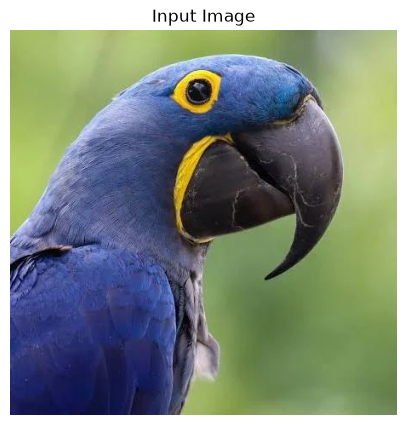

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image_path = "Photos/Parrot.png"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        f"Could not find {image_path}. Put the image in an 'images' folder "
        "next to this notebook or change image_path."
    )

# Convert from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

## Task 1 — 7×7 Box Filter

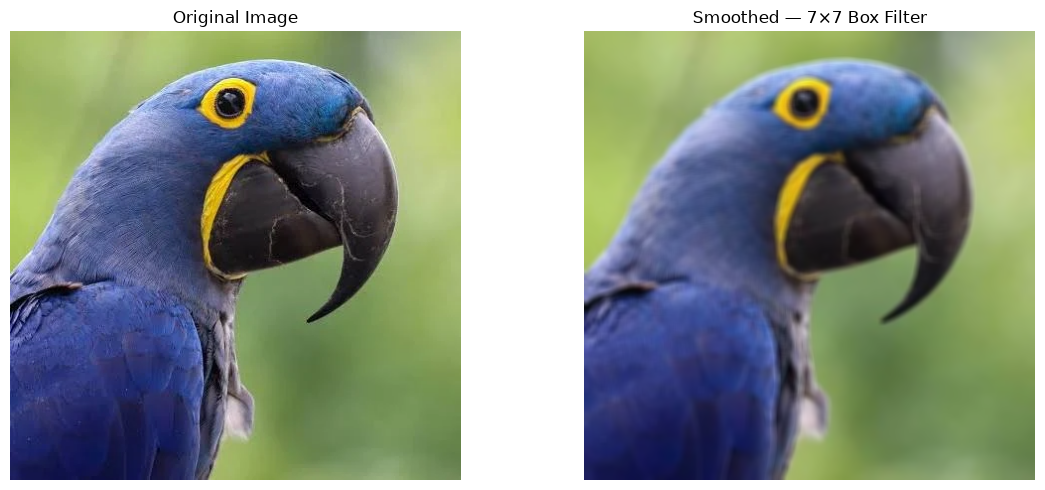

In [10]:
# Convert image to float32
image_float = image.astype(np.float32) / 255.0

# Create a normalized 7×7 box filter
box_kernel = np.ones((7, 7), dtype=np.float32) / 49.0

# Convolve the image with the 7×7 box filter
smoothed = cv2.filter2D(image_float, -1, box_kernel)

# Display original and smoothed images side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(np.clip(smoothed, 0, 1))
ax[1].set_title("Smoothed — 7×7 Box Filter")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Task 2 — 5×5 and 21×21 Gaussian Filters

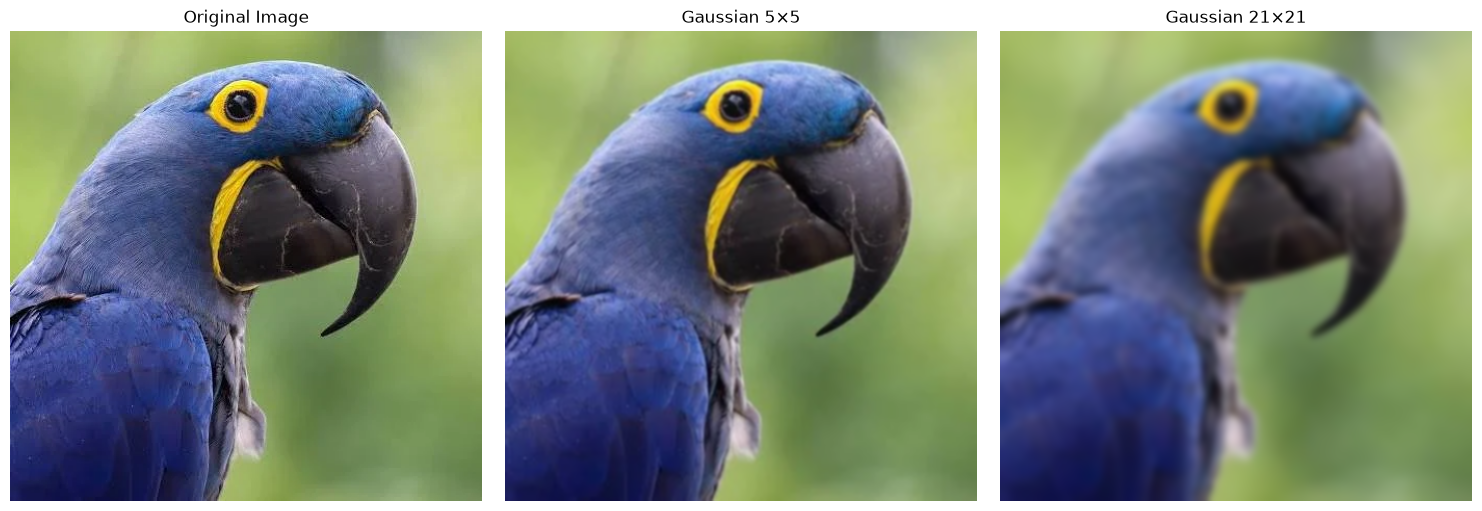

In [11]:
# Apply 5×5 Gaussian filter
gaussian_5 = cv2.GaussianBlur(
    image_float, (5, 5), sigmaX=0, sigmaY=0
)

# Apply 21×21 Gaussian filter
gaussian_21 = cv2.GaussianBlur(
    image_float, (21, 21), sigmaX=0, sigmaY=0
)

# Display the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(np.clip(gaussian_5, 0, 1))
ax[1].set_title("Gaussian 5×5")
ax[1].axis("off")

ax[2].imshow(np.clip(gaussian_21, 0, 1))
ax[2].set_title("Gaussian 21×21")
ax[2].axis("off")

plt.tight_layout()
plt.show()

## Task 3 — 3×3 Laplacian Filter for Sharpening

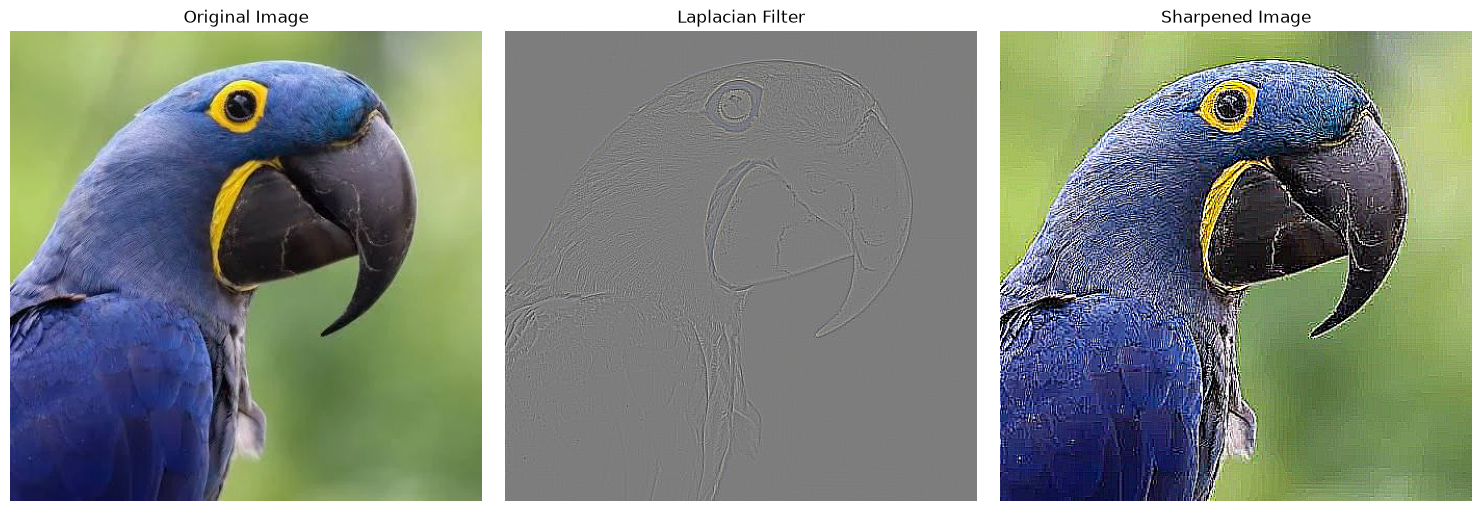

In [13]:
# Apply a 3×3 Laplacian filter
laplacian = cv2.Laplacian(
    image_float, cv2.CV_32F, ksize=3
)

# Sharpen the image using the formula from the manual
sharpened = np.clip(
    image_float - laplacian, 0, 1
)

# Normalize Laplacian only for visualization
laplacian_display = cv2.normalize(
    laplacian, None, 0, 1, cv2.NORM_MINMAX
)

# Plot the required three images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(laplacian_display)
ax[1].set_title("Laplacian Filter")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened Image")
ax[2].axis("off")

plt.tight_layout()
plt.show()